In [123]:
from pathlib import Path

files = sorted(Path("../data/images").glob("*.jpg")) + sorted(Path("../data/drawing").glob("*.png"))
print(f"Чертежей: {len(files)}")

Чертежей: 30


In [124]:
import cv2
import numpy as np


def load_sheet(file: Path):
    """Изображение листа (RGB) и полигоны OCR из кэша, (N, 4, 2) в px листа.

    Кэш пишет thick_lines.py,S пробелы в имени файла там заменены на '_'. Нет кэша - FileNotFoundError.
    """
    img = load_image(str(file))
    polys = np.load(f".cache/ocr_cache/{file.stem.replace(' ', '_')}.npy")
    return img, polys

In [125]:
import ipywidgets as widgets
from IPython.display import display
from matplotlib import pyplot as plt

from draftslice.core.io import load_image

file_names = [f.name for f in files]


def _view_img(filename: str):

    path = next(f for f in files if f.name == filename)
    img, polys = load_sheet(path)
    plt.figure(figsize=(16, 8))
    plt.imshow(img)
    plt.title(img.shape)
    plt.axis("off")
    plt.show()
    return img, polys


ui = widgets.interactive(_view_img, filename=file_names)
display(ui)

interactive(children=(Dropdown(description='filename', options=('1.jpg', '10.jpg', '11.jpg', '12.jpg', '13.jpg…

### Функции удаления текста

In [126]:
def get_half_wide_box(poly):
    """Возвращает bounding box полигона, расширенный на полвысоты строки."""
    (cx, cy), (w, h), a = cv2.minAreaRect(poly)
    m = min(w, h) / 2
    return np.round(cv2.boxPoints(((cx, cy), (w + 2 * m, h + 2 * m), a))).astype(np.int32)

def draw_tight_mask_and_get_boxes(shape, polys):
    """Создает точную маску полигонов и список расширенных боксов."""
    tight = np.zeros(shape, np.uint8)
    wide_boxes = []

    for poly in polys:
        # cv2.fillConvexPoly работает in-place, заливаем точную маску
        cv2.fillConvexPoly(tight, np.round(poly).astype(np.int32), 1)
        wide_boxes.append(get_half_wide_box(poly))

    return tight, wide_boxes

def check_components_in_wide_boxes(labels, binary, wide_boxes, comp_area, n_cc):
    """Проверяет, лежит ли каждая компонента ЦЕЛИКОМ внутри хотя бы одного wide_box."""
    img_h, img_w = binary.shape
    in_one_wide = np.zeros(n_cc, bool)
    
    for box in wide_boxes:
        # Ограничиваем координаты рамки размерами изображения
        x0, y0 = np.maximum(box.min(0), 0)
        x1, y1 = np.minimum(box.max(0) + 1, (img_w, img_h))

        # Создаем локальную маску (ROI) для текущего бокса
        roi = np.zeros((y1 - y0, x1 - x0), np.uint8)
        cv2.fillConvexPoly(roi, box - (x0, y0), 1)

        # Пиксели, принадлежащие и расширенному боксу, и исходным линиям
        sel = (roi > 0) & binary[y0:y1, x0:x1]
        
        local_labels = labels[y0:y1, x0:x1][sel]
        if local_labels.size > 0:
            # Считаем только те метки, которые есть в рамке (без minlength)
            local_counts = np.bincount(local_labels)
            
            # Получаем индексы только присутствующих компонент (исключая фон 0)
            present_labels = np.nonzero(local_counts)[0]
            if present_labels[0] == 0: 
                present_labels = present_labels[1:]
            
            # Проверяем площадь только для них и точечно обновляем in_one_wide
            is_full_inside = (local_counts[present_labels] == comp_area[present_labels])
            in_one_wide[present_labels[is_full_inside]] = True
        
    return in_one_wide

def clear_text(binary, polys):
    # Каждую полигонную область уменьшаем и закрашиваем
    tight_mask, wide_boxes = draw_tight_mask_and_get_boxes(binary.shape, polys)

    # Ищем связные компоненты
    n_cc, labels, stats, _ = cv2.connectedComponentsWithStats(binary.astype(np.uint8), connectivity=8)
    comp_area = stats[:, cv2.CC_STAT_AREA]

    # Компонента более чем на 50% площади лежит в точных полигонах
    valid_tight_pixels = (binary > 0) & (tight_mask == 1)
    in_tight = np.bincount(labels[valid_tight_pixels], minlength=n_cc)
    is_mostly_in_tight = (2 * in_tight > comp_area)

    # Компонента целиком лежит внутри одной расширенной рамки
    is_entirely_in_wide = check_components_in_wide_boxes(labels, binary, wide_boxes, comp_area, n_cc)

    # Объединяем условия (0-й индекс — это фон, его исключаем)
    is_text_cc = is_mostly_in_tight | is_entirely_in_wide
    is_text_cc[0] = False

    # Очищаем текст
    ink = binary & ~is_text_cc[labels]

    return ink.astype(np.uint8) * 255

In [127]:
from draftslice.core import preprocess

img, polys = ui.result

preprocessed = preprocess.preprocess(img, target=9, max_scale=2.0)
img = preprocessed.img
polys = polys * preprocessed.scale
ink = clear_text(preprocessed.binary > 0, polys)

print(f"scale: {preprocessed.scale} shape: {preprocessed.binary.shape} thick: {preprocessed.t_c}")

scale: 2.0 shape: (1036, 2170) thick: 2.9956281185150146


In [128]:
from draftslice.core.thick_lines.graph import build_graph

THICK_RATIO = 1.3
dist_map = cv2.distanceTransform(ink, distanceType=cv2.DIST_L2, maskSize=cv2.DIST_MASK_PRECISE)
g0 = build_graph(ink, dist_map, max_kink_deg=30.0, tol=0.9, thick_ratio=THICK_RATIO)
print("путей:", g0.n_paths)


путей: 109


In [129]:
def show_paths(img, g, win=None, min_len=0, width=16):
    """win = (y0, y1, x0, x1) — окно в координатах изображения; фигура подгоняется под его пропорции."""
    y0, y1, x0, x1 = win if win is not None else (0, img.shape[0], 0, img.shape[1])
    fig, ax = plt.subplots(figsize=(width, width * (y1 - y0) / (x1 - x0)))
    ax.imshow(img, cmap='gray')

    ends = []
    for i in range(g.n_paths):
        pts = g.path_coordinates(i)
        in_win = (pts[:, 0] >= y0) & (pts[:, 0] < y1) & (pts[:, 1] >= x0) & (pts[:, 1] < x1)
        if not in_win.any() or len(pts) < min_len:
            continue
        ends += [pts[0], pts[-1]]
        mid = pts[len(pts) // 2]
        ax.plot(pts[:, 1], pts[:, 0], lw=3.5)
        if y0 <= mid[0] < y1 and x0 <= mid[1] < x1:
            ax.text(mid[1], mid[0], str(i), color='red', fontsize=16,
                    bbox=dict(facecolor='white', alpha=0.6, pad=0.5, lw=0))

    nodes = np.unique(np.array(ends), axis=0)
    ax.scatter(nodes[:, 1], nodes[:, 0], s=100, c='yellow',
               edgecolors='black', linewidths=1.6, zorder=30,)

    ax.set_xlim(x0, x1)
    ax.set_ylim(y1, y0)
    ax.axis('off')
    plt.tight_layout()
    plt.show()


def show_paths_ui(img, g, size=1000):
    """Просмотр веток в окне: центр и размер окна ползунками; старт — середина изображения."""
    img_h, img_w = img.shape[:2]

    def _slider(value, hi, desc, lo=0):
        return widgets.IntSlider(value=value, min=lo, max=hi, step=10, description=desc, continuous_update=False)

    def _show(cy, cx, win_h, win_w):
        y0 = int(np.clip(cy - win_h // 2, 0, img_h - win_h))  # окно не выходит за край изображения
        x0 = int(np.clip(cx - win_w // 2, 0, img_w - win_w))
        show_paths(img, g, win=(y0, y0 + win_h, x0, x0 + win_w))

    widgets.interact(
        _show,
        cy=_slider(img_h // 2, img_h - 1, "центр y"),
        cx=_slider(img_w // 2, img_w - 1, "центр x"),
        win_h=_slider(min(size // 2, img_h), img_h, "высота", lo=50),
        win_w=_slider(min(size, img_w), img_w, "ширина", lo=50),
    )


show_paths_ui(img, g0)


interactive(children=(IntSlider(value=518, continuous_update=False, description='центр y', max=1035, step=10),…

линия 90: 103 точек, уровень 6.09 px, полоса ±1.3: [4.69, 7.92]
лучший возможный разрез: точка 85, отношение средних 1.07 (порог 1.3) -> не резать


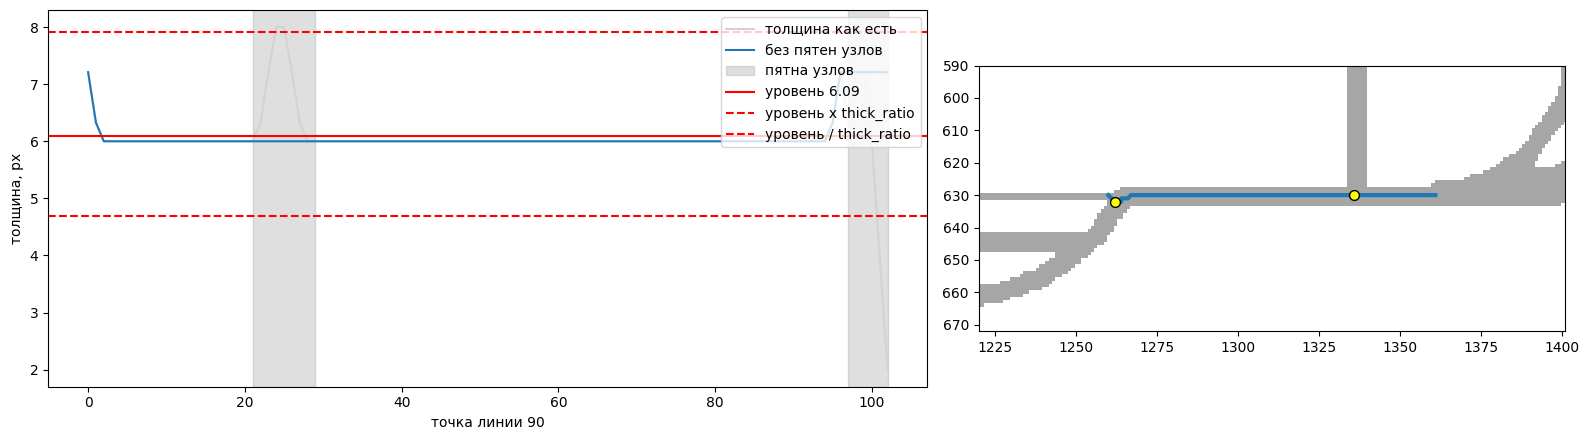

In [130]:
from draftslice.core.thick_lines.thickness import junction_free, skeleton_thickness

t_px = skeleton_thickness(g0, dist_map)


def show_line(i, min_len=3.0, margin=40):
    """Отладка линии i: профиль толщины, уровень линии и полоса thick_ratio; лучший возможный разрез и его отношение."""
    pix = g0.path(i)
    t, spots = junction_free(t_px[pix], g0.degrees[pix])
    lt = np.log(np.maximum(t, 1.0))
    level = float(np.exp(lt.mean()))  # уровень линии: среднее геометрическое толщины
    n = len(t)
    m = int(np.ceil(min_len * np.exp(np.median(lt))))  # обе части не короче min_len толщин
    msg = f"линия {i}: {n} точек, уровень {level:.2f} px, полоса ±{THICK_RATIO}: [{level / THICK_RATIO:.2f}, {level * THICK_RATIO:.2f}]"
    if n >= 2 * m:
        k = np.arange(m, n - m + 1)
        c = np.cumsum(lt)
        d = np.abs(c[k - 1] / k - (c[-1] - c[k - 1]) / (n - k))
        j = int(np.argmax(np.sqrt(k * (n - k) / n) * d))
        msg += f"\nлучший возможный разрез: точка {k[j]}, отношение средних {np.exp(d[j]):.2f} (порог {THICK_RATIO}) -> {'резать' if np.exp(d[j]) > THICK_RATIO else 'не резать'}"
    else:
        msg += f"\nрезать нечего: линия {n} точек короче двух минимальных частей ({m} + {m})"
    fig, (ax, im) = plt.subplots(1, 2, figsize=(16, 4.5), gridspec_kw={"width_ratios": [3, 2]})
    ax.plot(t_px[pix], color="lightgray", label="толщина как есть")
    ax.plot(t, color="tab:blue", label="без пятен узлов")
    ax.fill_between(np.arange(n), 0, 1, where=spots, color="gray", alpha=0.25, transform=ax.get_xaxis_transform(), label="пятна узлов")
    ax.axhline(level, color="red", label=f"уровень {level:.2f}")
    ax.axhline(level * THICK_RATIO, color="red", ls="--", label="уровень x thick_ratio")
    ax.axhline(level / THICK_RATIO, color="red", ls="--", label="уровень / thick_ratio")
    ax.set_xlabel(f"точка линии {i}")
    ax.set_ylabel("толщина, px")
    ax.legend(loc="upper right")
    yx = g0.coordinates[pix]
    im.imshow(ink > 0, cmap="Greys", alpha=0.35)
    im.plot(yx[:, 1], yx[:, 0], color="tab:blue", lw=3)
    nodes = yx[g0.degrees[pix] >= 3]
    im.scatter(nodes[:, 1], nodes[:, 0], c="yellow", edgecolors="k", s=50, zorder=5)
    im.set_xlim(yx[:, 1].min() - margin, yx[:, 1].max() + margin)
    im.set_ylim(yx[:, 0].max() + margin, yx[:, 0].min() - margin)
    plt.tight_layout()
    print(msg)
    return fig

IDX_LINE = 90


show_line(IDX_LINE)
plt.show()


горки (px): [2.24, 6.02], массы [0.39, 0.61], порог 4.33
классы разрешены
среднее 4.33, медиана 5.97


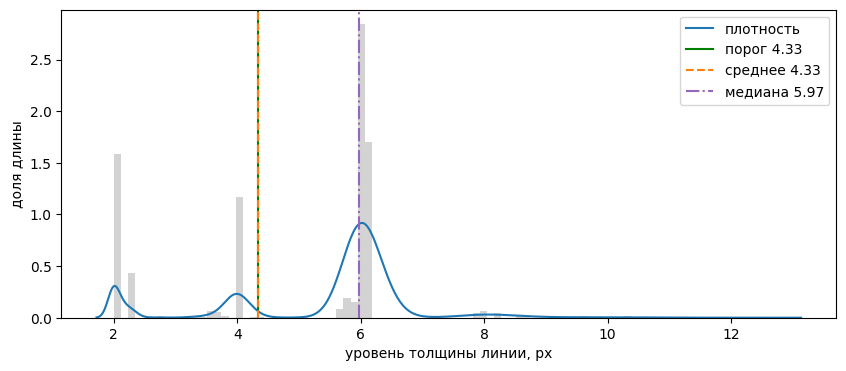

In [131]:
from draftslice.core.thick_lines.classify import classify_lines

THR_SCALE = 1.0 # ручка: множитель порога (больше — меньше толстых)


cls = classify_lines(g0, dist_map, thr_scale=THR_SCALE, bandwidth=0.05)
thick = cls.thick
print(f"горки (px): {[round(c, 2) for c in cls.centers]}, "
      f"массы {[round(m, 2) for m in cls.masses]}, "
      f"порог {None if cls.thr is None else round(cls.thr, 2)}")
print("классы разрешены" if cls.centers else "классы не разрешены "
"(один класс или горки слиплись): лист стоит пересчитать в большем масштабе")

lvl, w = cls.level, cls.length
mean = float(np.average(lvl))  # среднее с весом по длине
o = np.argsort(lvl)
median = float(lvl[o][np.searchsorted(np.cumsum(w[o]), w.sum() / 2)])  # медиана с весом по длине
print(f"среднее {mean:.2f}, медиана {median:.2f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(cls.level, bins=80, weights=cls.length, density=True, color="lightgray")
ax.plot(cls.grid, cls.dens, color="tab:blue", label="плотность")
if cls.thr is not None:
    ax.axvline(cls.thr, color="g", label=f"порог {cls.thr:.2f}")
ax.axvline(mean, color="tab:orange", ls="--", label=f"среднее {mean:.2f}")
ax.axvline(median, color="tab:purple", ls="-.", label=f"медиана {median:.2f}")
ax.set_xlabel("уровень толщины линии, px")
ax.set_ylabel("доля длины")
ax.legend()
plt.show()


контур 5.99 px; пики: нижний 2.02, контурный 6.02; порог между ними 4.75 (среднее 4.33); рамка: 1 линий
толстых: 47 (по среднему 49), отличаются 2 линий, 0.1% длины


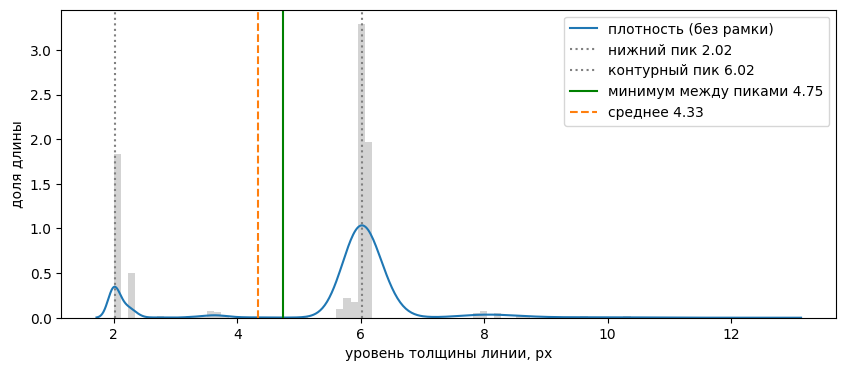

In [132]:
from scipy.signal import find_peaks

from draftslice.core.thick_lines.classify import _density

# рамка листа (линия с охватом >= 90 % листа по оси) не часть чертежа: исключаем её из статистики толщины
img_h, img_w = ink.shape
frame = np.array([
    np.ptp(g0.path_coordinates(i)[:, 1]) >= 0.9 * img_w or np.ptp(g0.path_coordinates(i)[:, 0]) >= 0.9 * img_h
    for i in range(g0.n_paths)
])
grid, dens = _density(cls.level[~frame], cls.length[~frame], 0.05)

t_contour = preprocessed.t_c * preprocessed.scale            # type: ignore # толщина контура в рабочем масштабе, px
pk, _ = find_peaks(dens, prominence=0.05 * dens.max())        # значимые пики плотности
hi = pk[np.argmin(np.abs(grid[pk] - t_contour))]              # контурный пик - ближайший к толщине контура
lo = pk[pk < hi][-1]                                          # ближайший значимый пик слева
v = lo + np.argmin(dens[lo:hi + 1])                           # минимум между двумя пиками
thr = float(grid[v])
thick = cls.level > thr

diff = thick != cls.thick                                     # cls.thick - прежний порог по среднему
print(f"контур {t_contour:.2f} px; пики: нижний {grid[lo]:.2f}, контурный {grid[hi]:.2f}; "
      f"порог между ними {thr:.2f} (среднее {cls.thr:.2f}); рамка: {frame.sum()} линий")
print(f"толстых: {thick.sum()} (по среднему {cls.thick.sum()}), отличаются {diff.sum()} линий, "
      f"{cls.length[diff].sum() / cls.length.sum():.1%} длины")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(cls.level[~frame], bins=80, weights=cls.length[~frame], density=True, color="lightgray")
ax.plot(grid, dens, color="tab:blue", label="плотность (без рамки)")
ax.axvline(grid[lo], color="gray", ls=":", label=f"нижний пик {grid[lo]:.2f}")
ax.axvline(grid[hi], color="gray", ls=":", label=f"контурный пик {grid[hi]:.2f}")
ax.axvline(thr, color="g", label=f"минимум между пиками {thr:.2f}")
ax.axvline(cls.thr, color="tab:orange", ls="--", label=f"среднее {cls.thr:.2f}")
ax.set_xlabel("уровень толщины линии, px")
ax.set_ylabel("доля длины")
ax.legend()
plt.show()


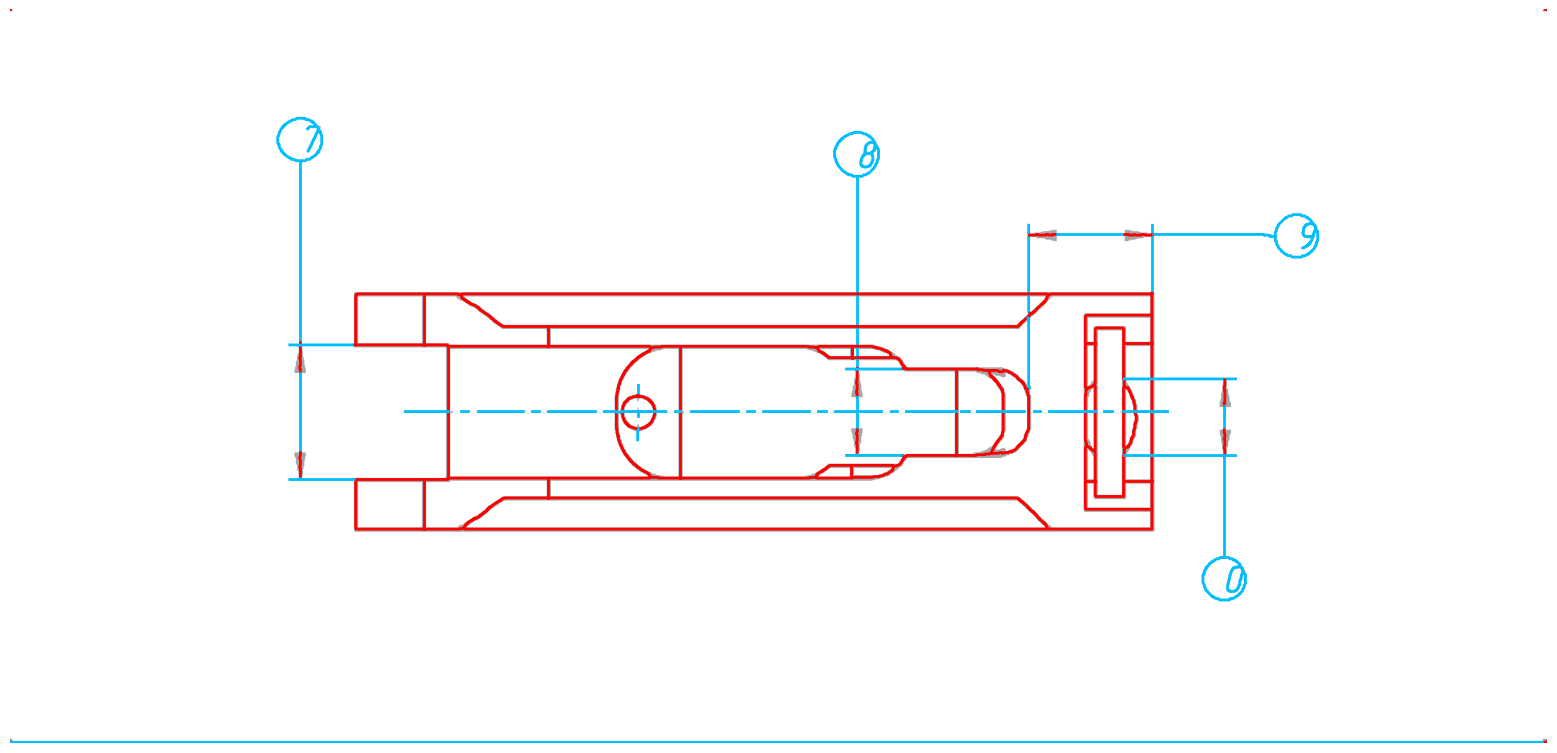

In [133]:
def show_class(win=None, width=16):
    """win = (y0, y1, x0, x1). Красный - толстый класс, голубой - тонкий."""
    y0, y1, x0, x1 = win if win is not None else (0, ink.shape[0], 0, ink.shape[1])
    fig, ax = plt.subplots(figsize=(width, width * (y1 - y0) / (x1 - x0)))
    ax.imshow(ink > 0, cmap="Greys", alpha=0.35)
    for i in range(g0.n_paths):
        pts = g0.path_coordinates(i)
        m = (pts[:, 0] >= y0) & (pts[:, 0] < y1) & (pts[:, 1] >= x0) & (pts[:, 1] < x1)
        if m.any():
            ax.plot(pts[m, 1], pts[m, 0], color="red" if thick[i] else "deepskyblue", lw=2)
    ax.set_xlim(x0, x1)
    ax.set_ylim(y1, y0)
    ax.axis("off")
    plt.tight_layout()
    return fig


show_class()
plt.show()
